# Q Learning
-----------------------------
1. Q 러닝을 쓰는 이유:
- 택시 배차는 현재 행동이 미래 상태와 미래 보상에 영향을 준다
- 그래서 즉시 가까운 차만 보내는 greedy한 규칙보다, 누적 보상을 최대화하는 정책이 필요하다
- 작은 상태공간에서는 이 누적 보상을 Q-table 로 학습할 수 있다
- 따라서 Q-learning은 작은 문제에서의 기준 강화학습 방법으로 적절하다
## 단계 1: 환경 생성
---------------
- gymnasium.make("Taxi-v3")
- 상태 수, 행동 수 확인
- Q-table 초기화
## 단계 2: 행동 선택
-----------------
- ε-greedy 정책 사용
- 확률 ε로 랜덤 행동
- 확률 1-ε로 argmax(Q[state])
## 단계 3: Q-table 업데이트
-----------------------
- 한 step마다 TD update 수행
- 수식은 Q[s, a] = Q[s, a] + alpha * (reward + gamma * max(Q[s_next]) - Q[s, a])
## 단계 4: 학습 기록
-------------------------
- episode reward
- episode length
- epsilon 변화
- 최근 100개 episode 평균 reward
## 단계 5: 학습 후 평가
----------------------
- epsilon=0으로 greedy policy 실행
- 평균 reward / 평균 step 수 측정
- 몇 개 episode는 render해서 정책 확인

### 기본 학습 코드:

In [3]:
!pip -q install gymnasium

import numpy as np
import random
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import deque

# 1. Seed 고정
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# 2. 환경 생성
env = gym.make("Taxi-v3")

n_states = env.observation_space.n   # 500
n_actions = env.action_space.n       # 6

print("Number of states:", n_states)
print("Number of actions:", n_actions)

# 3. Q-table 초기화
Q_table = np.zeros((n_states, n_actions))

# 4. 하이퍼파라미터 설정
num_episodes = 5000
max_steps = 200

alpha = 0.1          # learning rate
gamma = 0.99         # discount factor

epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.999

# 5. epsilon-greedy action 선택
def epsilon_greedy_action(state, Q_table, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    else:
        return np.argmax(Q_table[state])

# 6. 학습 기록용
episode_rewards = []
episode_lengths = []
moving_avg_rewards = []

reward_window = deque(maxlen=100)

# 7. Q-learning 학습
for episode in range(num_episodes):
    state, info = env.reset(seed=SEED + episode)
    done = False
    total_reward = 0
    step_count = 0

    for step in range(max_steps):
        action = epsilon_greedy_action(state, Q_table, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Q-learning update
        best_next_q = np.max(Q_table[next_state])
        td_target = reward + gamma * best_next_q * (not done)
        td_error = td_target - Q_table[state, action]

        Q_table[state, action] += alpha * td_error

        state = next_state
        total_reward += reward
        step_count += 1

        if done:
            break

    # epsilon decay
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # 기록
    episode_rewards.append(total_reward)
    episode_lengths.append(step_count)
    reward_window.append(total_reward)
    moving_avg_rewards.append(np.mean(reward_window))

    if (episode + 1) % 500 == 0:
        print(f"Episode {episode+1:4d} | "
              f"Reward: {total_reward:4d} | "
              f"Avg(100): {moving_avg_rewards[-1]:7.2f} | "
              f"Epsilon: {epsilon:.4f}")

env.close()

print("Training finished.")

Number of states: 500
Number of actions: 6
Episode  500 | Reward: -574 | Avg(100): -359.11 | Epsilon: 0.6064
Episode 1000 | Reward:  -56 | Avg(100):  -63.68 | Epsilon: 0.3677
Episode 1500 | Reward:  -52 | Avg(100):  -12.62 | Epsilon: 0.2230
Episode 2000 | Reward:    1 | Avg(100):   -0.96 | Epsilon: 0.1352
Episode 2500 | Reward:   12 | Avg(100):    3.86 | Epsilon: 0.0820
Episode 3000 | Reward:   -5 | Avg(100):    4.55 | Epsilon: 0.0497
Episode 3500 | Reward:   14 | Avg(100):    6.37 | Epsilon: 0.0301
Episode 4000 | Reward:   -2 | Avg(100):    6.72 | Epsilon: 0.0183
Episode 4500 | Reward:    8 | Avg(100):    7.81 | Epsilon: 0.0111
Episode 5000 | Reward:   10 | Avg(100):    6.82 | Epsilon: 0.0100
Training finished.


### 학습 곡선 시각화

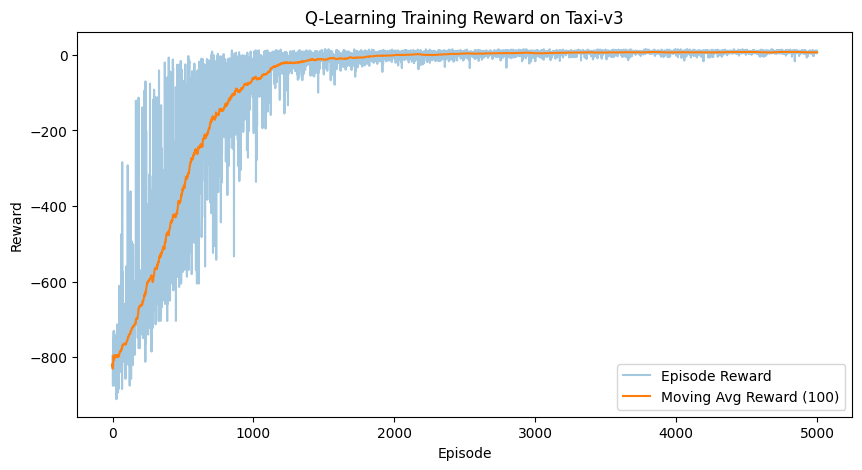

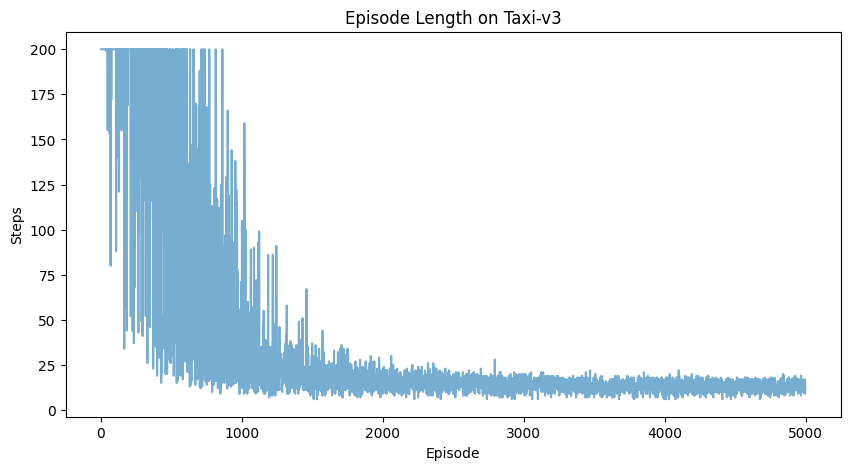

In [4]:
# 8. 학습 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.4, label="Episode Reward")
plt.plot(moving_avg_rewards, label="Moving Avg Reward (100)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-Learning Training Reward on Taxi-v3")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(episode_lengths, alpha=0.6)
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("Episode Length on Taxi-v3")
plt.show()

### 학습된 정책 평가 코드

In [5]:
# 9. 학습된 정책 평가
def evaluate_policy(env, Q_table, n_eval_episodes=100):
    rewards = []
    lengths = []

    for episode in range(n_eval_episodes):
        state, info = env.reset(seed=1000 + episode)
        done = False
        total_reward = 0
        step_count = 0

        while not done:
            action = np.argmax(Q_table[state])  # greedy
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            state = next_state
            total_reward += reward
            step_count += 1

        rewards.append(total_reward)
        lengths.append(step_count)

    return np.mean(rewards), np.mean(lengths)

eval_env = gym.make("Taxi-v3")
avg_reward, avg_length = evaluate_policy(eval_env, Q_table, n_eval_episodes=100)

print(f"Average evaluation reward: {avg_reward:.2f}")
print(f"Average evaluation steps : {avg_length:.2f}")

eval_env.close()

Average evaluation reward: 7.63
Average evaluation steps : 13.37


## 실제로 렌더링 해보기

In [6]:
# 10. 학습된 정책 시연
demo_env = gym.make("Taxi-v3", render_mode="ansi")

for episode in range(3):
    state, info = demo_env.reset(seed=2000 + episode)
    done = False
    total_reward = 0

    print(f"\n===== Demo Episode {episode+1} =====")
    print(demo_env.render())

    while not done:
        action = np.argmax(Q_table[state])
        next_state, reward, terminated, truncated, info = demo_env.step(action)
        done = terminated or truncated
        state = next_state
        total_reward += reward

        print(demo_env.render())

    print("Total reward:", total_reward)

demo_env.close()


===== Demo Episode 1 =====
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Pickup)

+---------+
|R: | :_:G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

+---------+
|R: | : :G|
| : | :_: |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

+---------+
|R: | : :G|
| : |_: : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

+---------+
|R: | : :G|
| : | : : |
| : :_: : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

+---------+
|R: | : :G|
| : | : : |
| :_: : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

+---------+
|R: | : :G|
| : | : : |
|_: : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

+---------+
|R: | : :G|
| : | : : 

# Q Learning 개선

## 1. 수업 때 진행한 택시 과제(Assignment2)와의 차별점
- Assignment2에서는 Q Learning이 돌아가는지만 봤는데 이번 코드는
  - 왜 Q Learning을 쓰는지 설명
  - 학습 과정 기록
  - 성능 평가
  - 시각화
  - DQN과 비교  
  까지 들어가 있어서 더 체계적으로 택시 문제를 해결하고자 한다
- 이번 코드는 학습이 훨씬 잘 되도록 튜닝됨
  - Assignment2 코드는 num_episodes=1000, eps_decay=0.9999로 되어있어서 이 조합이면 학습이 끝나도 epsilon이 너무 높게 남음. 즉 끝까지 랜덤 행동 비중이 커서 정책이 잘 정리되지 않음
  - 이번 코드는 num_episodes=5000, eps_decay=0.999이라서 exploration -> exploitation 전환이 훨씬 잘 일어나도 결과적으로 성능도 많이 좋아짐
- Assignment2와 달리 이번 코드에서는 Q Learning의 episode reward, episode length, episode average를 저장해서 학습 초반/중반/후반의 변화까지 볼 수 있음
- 이번 코드는 Q Learning과 DQN이 비교 가능한 기준선 역할을 함
  - 수업 코드는 Q-learning 단독 실습이지만, 이번 프로젝트 같은 문제에서 Q-learning과 DQN을 같이 돌려서
  - 작은 상태공간에서는 Q-learning도 강함
  - 상태공간이 커지면 DQN이 더 확장 가능함

## 기본 Q-learning 학습 코드
####이전 코드와의 차이  
이 단계에서는 수업 코드 대비 아래가 바뀜:  
- defaultdict 대신 고정 크기 Q-table
- 학습 횟수 증가: 1000 → 8000
- epsilon decay 개선
- episode reward / step / moving average 저장
- seed 고정으로 재현성 향상

####개선 이유
- Taxi-v3는 상태 수가 정확히 500개라서 dense table이 더 직관적임
- 더 오래 학습해야 greedy policy가 안정됨
- 기록을 남겨야 나중에 시각화 가능

In [7]:
!pip -q install gymnasium

import numpy as np
import random
import gymnasium as gym
from collections import deque
import matplotlib.pyplot as plt

# 1. Seed 고정
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# 2. 환경 생성
env = gym.make("Taxi-v3")

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of states:", n_states)
print("Number of actions:", n_actions)

# 3. Q-table 초기화
Q_table = np.zeros((n_states, n_actions), dtype=np.float32)

# 4. 하이퍼파라미터
num_episodes = 8000
max_steps = 200

alpha = 0.1
gamma = 0.99

epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.9992

# 5. epsilon-greedy 행동 선택
def epsilon_greedy_action(state, Q_table, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(Q_table[state])

# 6. 학습 기록용
episode_rewards = []
episode_lengths = []
moving_avg_rewards = []

reward_window = deque(maxlen=100)

# 7. 학습
for episode in range(num_episodes):
    state, info = env.reset(seed=SEED + episode)
    done = False
    total_reward = 0
    step_count = 0

    for step in range(max_steps):
        action = epsilon_greedy_action(state, Q_table, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        best_next_q = np.max(Q_table[next_state])
        td_target = reward + gamma * best_next_q * (not done)
        td_error = td_target - Q_table[state, action]
        Q_table[state, action] += alpha * td_error

        state = next_state
        total_reward += reward
        step_count += 1

        if done:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    episode_rewards.append(total_reward)
    episode_lengths.append(step_count)

    reward_window.append(total_reward)
    moving_avg_rewards.append(np.mean(reward_window))

    if (episode + 1) % 500 == 0:
        print(
            f"Episode {episode+1:4d} | "
            f"Reward: {total_reward:4d} | "
            f"Avg(100): {moving_avg_rewards[-1]:7.2f} | "
            f"Epsilon: {epsilon:.4f}"
        )

env.close()
print("Training finished.")

Number of states: 500
Number of actions: 6
Episode  500 | Reward: -134 | Avg(100): -400.44 | Epsilon: 0.6702
Episode 1000 | Reward:  -30 | Avg(100):  -90.04 | Epsilon: 0.4492
Episode 1500 | Reward:  -98 | Avg(100):  -24.22 | Epsilon: 0.3010
Episode 2000 | Reward:    7 | Avg(100):   -6.58 | Epsilon: 0.2018
Episode 2500 | Reward:   14 | Avg(100):   -1.22 | Epsilon: 0.1352
Episode 3000 | Reward:    5 | Avg(100):    2.94 | Epsilon: 0.0906
Episode 3500 | Reward:   14 | Avg(100):    4.89 | Epsilon: 0.0607
Episode 4000 | Reward:    6 | Avg(100):    5.18 | Epsilon: 0.0407
Episode 4500 | Reward:    8 | Avg(100):    6.99 | Epsilon: 0.0273
Episode 5000 | Reward:    9 | Avg(100):    6.84 | Epsilon: 0.0183
Episode 5500 | Reward:    7 | Avg(100):    7.28 | Epsilon: 0.0123
Episode 6000 | Reward:    8 | Avg(100):    7.62 | Epsilon: 0.0100
Episode 6500 | Reward:   13 | Avg(100):    7.59 | Epsilon: 0.0100
Episode 7000 | Reward:    7 | Avg(100):    6.75 | Epsilon: 0.0100
Episode 7500 | Reward:   -6 | Avg

## 개선 버전
####위 코드보다 추가로 개선된 점:

- 랜덤 tie-breaking
  - argmax가 같은 값이면 항상 같은 행동을 고르지 않고 랜덤 선택
- best Q-table 저장
  - 마지막 Q-table이 아니라, 최근 100개 평균 보상이 가장 좋았던 시점의 테이블 저장
- 학습 안정성 강화
  - 중간에 fluctuation이 있어도 가장 좋은 정책을 보존 가능

In [8]:
!pip -q install gymnasium

import numpy as np
import random
import gymnasium as gym
from collections import deque
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

env = gym.make("Taxi-v3")

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of states:", n_states)
print("Number of actions:", n_actions)

Q_table = np.zeros((n_states, n_actions), dtype=np.float32)

num_episodes = 8000
max_steps = 200

alpha = 0.1
gamma = 0.99

epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.9992

def epsilon_greedy_action(state, Q_table, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)

    q_values = Q_table[state]
    best_actions = np.flatnonzero(q_values == q_values.max())
    return np.random.choice(best_actions)

episode_rewards = []
episode_lengths = []
moving_avg_rewards = []

reward_window = deque(maxlen=100)

best_Q_table = None
best_moving_avg = -np.inf

for episode in range(num_episodes):
    state, info = env.reset(seed=SEED + episode)
    done = False
    total_reward = 0
    step_count = 0

    for step in range(max_steps):
        action = epsilon_greedy_action(state, Q_table, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        best_next_q = np.max(Q_table[next_state])
        td_target = reward + gamma * best_next_q * (not done)
        td_error = td_target - Q_table[state, action]
        Q_table[state, action] += alpha * td_error

        state = next_state
        total_reward += reward
        step_count += 1

        if done:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    episode_rewards.append(total_reward)
    episode_lengths.append(step_count)

    reward_window.append(total_reward)
    current_mavg = np.mean(reward_window)
    moving_avg_rewards.append(current_mavg)

    if len(reward_window) == 100 and current_mavg > best_moving_avg:
        best_moving_avg = current_mavg
        best_Q_table = Q_table.copy()

    if (episode + 1) % 500 == 0:
        print(
            f"Episode {episode+1:4d} | "
            f"Reward: {total_reward:4d} | "
            f"Avg(100): {current_mavg:7.2f} | "
            f"Epsilon: {epsilon:.4f}"
        )

env.close()

if best_Q_table is None:
    best_Q_table = Q_table.copy()

print("Training finished.")
print("Best moving average reward (100):", round(best_moving_avg, 2))

Number of states: 500
Number of actions: 6
Episode  500 | Reward: -312 | Avg(100): -394.82 | Epsilon: 0.6702
Episode 1000 | Reward:   -7 | Avg(100):  -78.80 | Epsilon: 0.4492
Episode 1500 | Reward:  -50 | Avg(100):  -24.62 | Epsilon: 0.3010
Episode 2000 | Reward:  -14 | Avg(100):   -6.75 | Epsilon: 0.2018
Episode 2500 | Reward:   13 | Avg(100):   -1.20 | Epsilon: 0.1352
Episode 3000 | Reward:    3 | Avg(100):    2.62 | Epsilon: 0.0906
Episode 3500 | Reward:   14 | Avg(100):    4.84 | Epsilon: 0.0607
Episode 4000 | Reward:   -3 | Avg(100):    5.24 | Epsilon: 0.0407
Episode 4500 | Reward:    8 | Avg(100):    7.15 | Epsilon: 0.0273
Episode 5000 | Reward:   10 | Avg(100):    6.76 | Epsilon: 0.0183
Episode 5500 | Reward:    7 | Avg(100):    7.25 | Epsilon: 0.0123
Episode 6000 | Reward:    8 | Avg(100):    7.75 | Epsilon: 0.0100
Episode 6500 | Reward:   13 | Avg(100):    7.58 | Epsilon: 0.0100
Episode 7000 | Reward:    7 | Avg(100):    6.90 | Epsilon: 0.0100
Episode 7500 | Reward:    4 | Avg

## 평가코드
- Assignment2 코드:
  - 평균 reward만 봄
- 기존 Q Learning 코드:
  - 평균 reward + 평균 steps
- 이번 개선 코드:
  - 평균 reward
  - 평균 steps
  - 성공 비율
  - 고품질 episode 비율  
  까지 확인 가능

In [9]:
def evaluate_policy(env, Q_table, n_eval_episodes=200):
    rewards = []
    lengths = []

    for episode in range(n_eval_episodes):
        state, info = env.reset(seed=1000 + episode)
        done = False
        total_reward = 0
        step_count = 0

        while not done:
            q_values = Q_table[state]
            best_actions = np.flatnonzero(q_values == q_values.max())
            action = np.random.choice(best_actions)

            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            state = next_state
            total_reward += reward
            step_count += 1

        rewards.append(total_reward)
        lengths.append(step_count)

    rewards = np.array(rewards)
    lengths = np.array(lengths)

    print(f"Average evaluation reward: {rewards.mean():.2f}")
    print(f"Average evaluation steps : {lengths.mean():.2f}")
    print(f"Success ratio (reward >= 0): {(rewards >= 0).mean():.3f}")
    print(f"High-quality episodes (reward >= 8): {(rewards >= 8).mean():.3f}")

    return rewards, lengths

eval_env = gym.make("Taxi-v3")
eval_rewards, eval_lengths = evaluate_policy(eval_env, best_Q_table, n_eval_episodes=200)
eval_env.close()

Average evaluation reward: 7.96
Average evaluation steps : 13.04
Success ratio (reward >= 0): 1.000
High-quality episodes (reward >= 8): 0.520


## 시각화

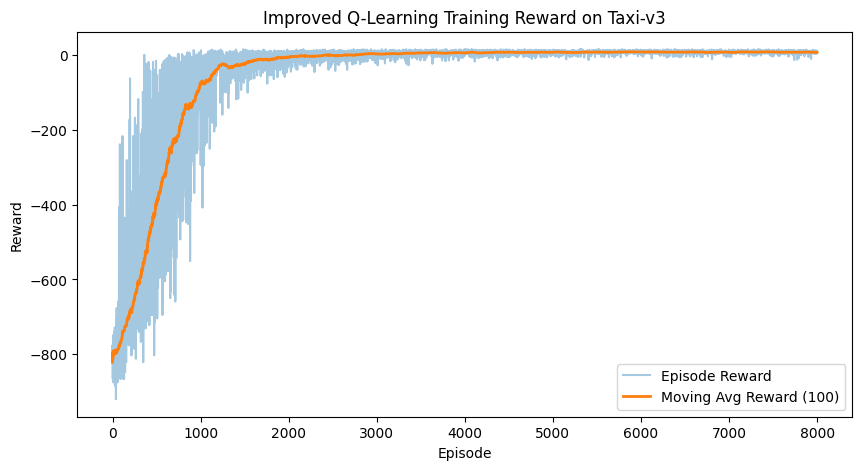

In [10]:
# 학습 reward / moving average 시각화
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.4, label="Episode Reward")
plt.plot(moving_avg_rewards, linewidth=2, label="Moving Avg Reward (100)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Improved Q-Learning Training Reward on Taxi-v3")
plt.legend()
plt.show()

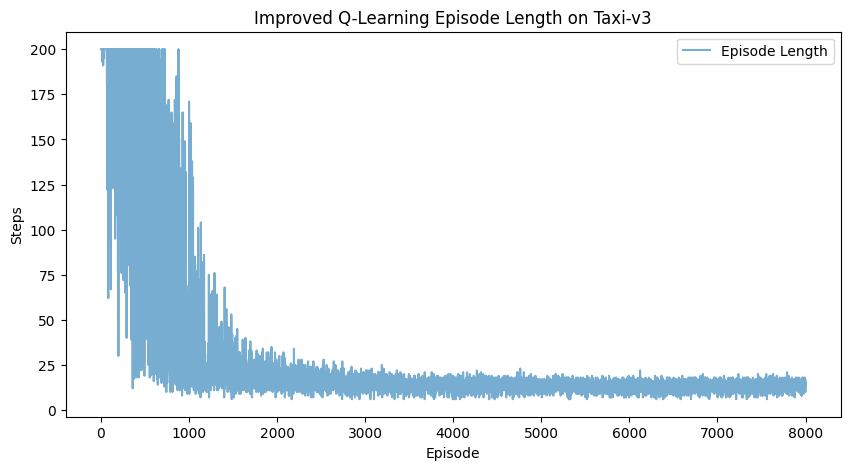

In [11]:
# episode length 시각화
plt.figure(figsize=(10, 5))
plt.plot(episode_lengths, alpha=0.6, label="Episode Length")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("Improved Q-Learning Episode Length on Taxi-v3")
plt.legend()
plt.show()

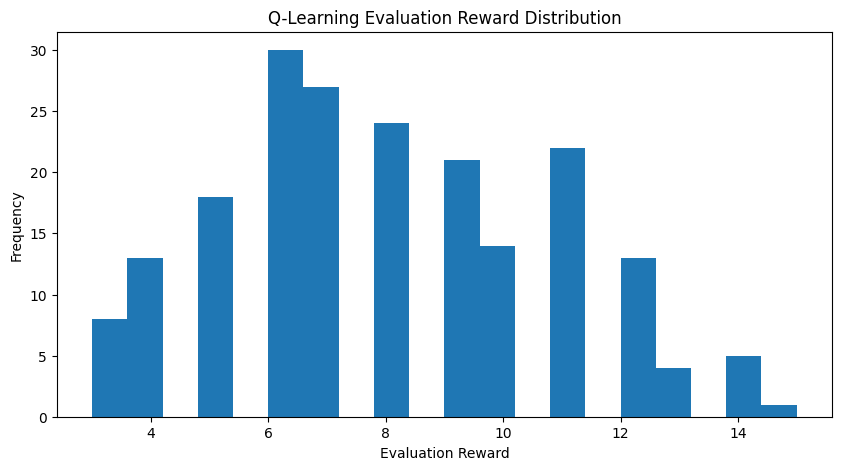

In [12]:
# 평가 reward 분포 시각화
plt.figure(figsize=(10, 5))
plt.hist(eval_rewards, bins=20)
plt.xlabel("Evaluation Reward")
plt.ylabel("Frequency")
plt.title("Q-Learning Evaluation Reward Distribution")
plt.show()

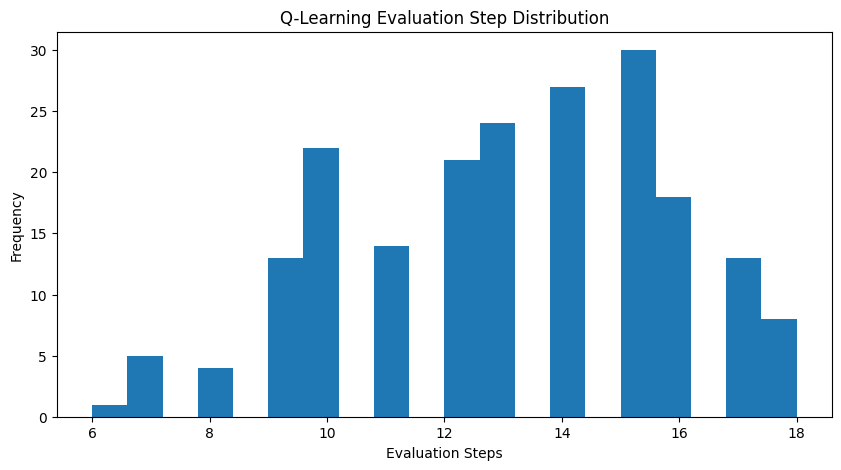

In [13]:
# 평가 step 분포 시각화
plt.figure(figsize=(10, 5))
plt.hist(eval_lengths, bins=20)
plt.xlabel("Evaluation Steps")
plt.ylabel("Frequency")
plt.title("Q-Learning Evaluation Step Distribution")
plt.show()

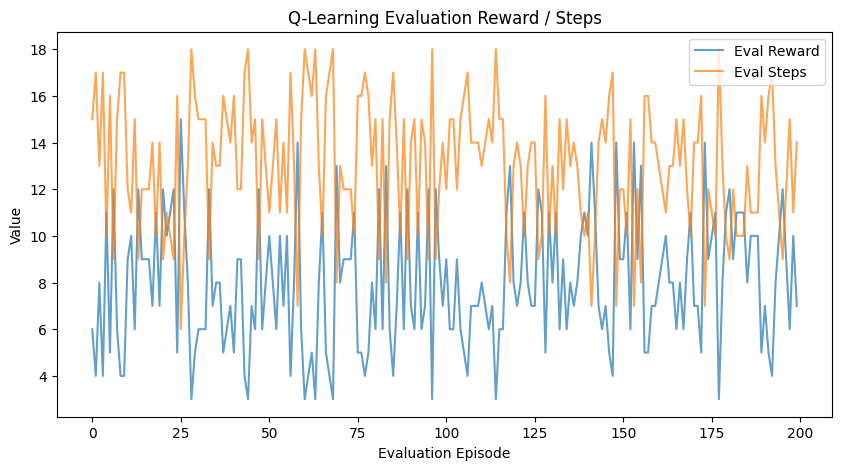

In [14]:
# reward와 step을 같이 비교하는 선 그래프
plt.figure(figsize=(10, 5))
plt.plot(eval_rewards, alpha=0.7, label="Eval Reward")
plt.plot(eval_lengths, alpha=0.7, label="Eval Steps")
plt.xlabel("Evaluation Episode")
plt.ylabel("Value")
plt.title("Q-Learning Evaluation Reward / Steps")
plt.legend()
plt.show()

## 렌더링

In [15]:
demo_env = gym.make("Taxi-v3", render_mode="ansi")

for episode in range(3):
    state, info = demo_env.reset(seed=2000 + episode)
    done = False
    total_reward = 0

    print(f"\n===== Demo Episode {episode+1} =====")
    print(demo_env.render())

    while not done:
        q_values = best_Q_table[state]
        best_actions = np.flatnonzero(q_values == q_values.max())
        action = np.random.choice(best_actions)

        next_state, reward, terminated, truncated, info = demo_env.step(action)
        done = terminated or truncated
        state = next_state
        total_reward += reward

        print(demo_env.render())

    print("Total reward:", total_reward)

demo_env.close()


===== Demo Episode 1 =====
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Pickup)

+---------+
|R: | : :G|
| : | : :_|
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

+---------+
|R: | : :G|
| : | :_: |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

+---------+
|R: | : :G|
| : |_: : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

+---------+
|R: | : :G|
| : | : : |
| : :_: : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

+---------+
|R: | : :G|
| : | : : |
| :_: : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

+---------+
|R: | : :G|
| : | : : |
|_: : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

+---------+
|R: | : :G|
| : | : : 

## Q Learning 결론
- Q-Learning은 Taxi-v3 환경에서 학습이 안정적으로 진행되었고, episode가 증가할수록 평균 보상이 점진적으로 향상되었다.
- 기본 Q-Learning 평가 결과는 평균 reward 7.63, 평균 step 13.37로, 작은 이산 상태공간에서는 Q-table 방식이 충분히 효과적임을 확인할 수 있었다.
- 개선된 Q-Learning에서는 epsilon decay 조정, tie-breaking 개선, best Q-table 저장 등을 반영해 평균 reward를 7.96, 평균 step을 13.04까지 높였다.
- 특히 성공 비율이 1.000으로 나타나, 학습된 정책이 대부분의 episode에서 안정적으로 목표를 달성했음을 확인했다.
- 수업 때(Assignment2) 사용한 과제용 코드의 평균 reward가 -91.44였던 것과 비교하면, 이번 프로젝트의 Q-Learning은 학습 구조와 평가 방식을 개선하여 성능을 크게 끌어올린 버전이라고 볼 수 있다.
- 또한 같은 환경에서 DQN과 비교했을 때도 Q-Learning이 비슷하거나 더 좋은 성능을 보여, 현재와 같은 작은 상태공간에서는 Q-Learning이 매우 강력한 baseline임을 확인했다.
- 다만 실제 택시 배차 문제처럼 상태공간과 변수 수가 커지는 경우에는 Q-table 방식의 한계가 있으므로, Q-Learning은 작은 환경에서의 기준선 모델로 의미가 있다고 정리할 수 있다.

# DQN
-----------------------------
1. DQN을 쓰는 이유:
- 택시 배차 문제는 현재 행동이 미래 상태와 미래 보상에 영향을 준다
- Q-learning은 작은 상태공간에서는 효과적이지만, 상태 수가 커지면 Q-table 방식은 비효율적이다
- DQN은 Q값을 테이블 대신 신경망으로 근사하여 더 큰 상태공간에도 확장 가능하다
- 따라서 DQN은 택시 배차 최적화 문제를 더 일반적인 방식으로 다룰 수 있는 강화학습 방법이다

## 단계 1: 환경 생성
---------------
- gymnasium.make("Taxi-v3")
- 상태 수, 행동 수 확인
- 상태를 one-hot 벡터로 변환하는 함수 정의

## 단계 2: DQN 구성
-----------------
- Q-network 정의
- target network 정의
- replay buffer 정의

## 단계 3: 행동 선택
-----------------
- ε-greedy 정책 사용
- 확률 ε로 랜덤 행동
- 확률 1-ε로 Q-network의 argmax 행동 선택

## 단계 4: DQN 업데이트
-----------------------
- transition (s, a, r, s')를 replay buffer에 저장
- mini-batch 샘플링
- target Q값 계산
- MSE loss로 network 학습
- 일정 주기마다 target network 업데이트

## 단계 5: 학습 기록
-------------------------
- episode reward
- episode length
- epsilon 변화
- 최근 100개 episode 평균 reward

## 단계 6: 학습 후 평가
----------------------
- epsilon=0으로 greedy policy 실행
- 평균 reward / 평균 step 수 측정
- 몇 개 episode는 render해서 정책 확인

### 기본 학습 코드:

In [16]:
# 1. Seed 고정
# 2. 환경 생성
# 3. 상태/행동 수 확인
# 4. one-hot 인코딩 함수 정의
# 5. QNetwork 클래스 정의
# 6. ReplayBuffer 클래스 정의
# 7. 하이퍼파라미터 설정
# 8. online network / target network 생성
# 9. epsilon-greedy action 선택 함수
# 10. train_step 함수
# 11. 전체 학습 루프
# 12. episode_rewards, episode_lengths, moving_avg_rewards 저장

In [17]:
!pip -q install gymnasium torch

import numpy as np
import random
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# 1. Seed 고정
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# 2. 환경 생성
env = gym.make("Taxi-v3")

n_states = env.observation_space.n   # 500
n_actions = env.action_space.n       # 6

print("Number of states:", n_states)
print("Number of actions:", n_actions)

# 3. 상태 one-hot 인코딩 함수
def encode_state(state):
    x = np.zeros(n_states, dtype=np.float32)
    x[state] = 1.0
    return x

# 4. Q-network 정의
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

# 5. Replay Buffer 정의
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)

# 6. 하이퍼파라미터 설정
num_episodes = 3000
max_steps = 200

gamma = 0.99
learning_rate = 1e-3

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

batch_size = 64
buffer_size = 10000
target_update_freq = 20

# 7. 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 8. 네트워크 / optimizer / replay buffer 생성
q_net = QNetwork(n_states, n_actions).to(device)
target_net = QNetwork(n_states, n_actions).to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=learning_rate)
memory = ReplayBuffer(buffer_size)

# 9. epsilon-greedy action 선택
def epsilon_greedy_action(state_vec, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    else:
        state_tensor = torch.FloatTensor(state_vec).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = q_net(state_tensor)
        return torch.argmax(q_values, dim=1).item()

# 10. DQN 학습 step
def train_step():
    if len(memory) < batch_size:
        return None

    states, actions, rewards, next_states, dones = memory.sample(batch_size)

    states = torch.FloatTensor(states).to(device)
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    next_states = torch.FloatTensor(next_states).to(device)
    dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

    # 현재 Q(s,a)
    current_q = q_net(states).gather(1, actions)

    # target Q 계산
    with torch.no_grad():
        next_q = target_net(next_states).max(dim=1, keepdim=True)[0]
        target_q = rewards + gamma * next_q * (1 - dones)

    loss = F.mse_loss(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

# 11. 학습 기록용
episode_rewards = []
episode_lengths = []
moving_avg_rewards = []

reward_window = deque(maxlen=100)

# 12. DQN 학습 루프
for episode in range(num_episodes):
    state, info = env.reset(seed=SEED + episode)
    state_vec = encode_state(state)

    done = False
    total_reward = 0
    step_count = 0

    while not done and step_count < max_steps:
        action = epsilon_greedy_action(state_vec, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        next_state_vec = encode_state(next_state)

        memory.push(state_vec, action, reward, next_state_vec, done)
        train_step()

        state_vec = next_state_vec
        total_reward += reward
        step_count += 1

    # epsilon decay
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # target network 업데이트
    if (episode + 1) % target_update_freq == 0:
        target_net.load_state_dict(q_net.state_dict())

    # 기록 저장
    episode_rewards.append(total_reward)
    episode_lengths.append(step_count)

    reward_window.append(total_reward)
    moving_avg_rewards.append(np.mean(reward_window))

    if (episode + 1) % 100 == 0:
        print(f"Episode {episode+1:4d} | "
              f"Reward: {total_reward:6.1f} | "
              f"Avg(100): {moving_avg_rewards[-1]:6.2f} | "
              f"Epsilon: {epsilon:.3f}")

env.close()

Number of states: 500
Number of actions: 6
Device: cuda
Episode  100 | Reward: -488.0 | Avg(100): -638.36 | Epsilon: 0.606
Episode  200 | Reward: -362.0 | Avg(100): -456.25 | Epsilon: 0.367
Episode  300 | Reward: -353.0 | Avg(100): -341.70 | Epsilon: 0.222
Episode  400 | Reward: -299.0 | Avg(100): -272.66 | Epsilon: 0.135
Episode  500 | Reward: -245.0 | Avg(100): -237.07 | Epsilon: 0.082
Episode  600 | Reward: -149.0 | Avg(100): -193.93 | Epsilon: 0.050
Episode  700 | Reward: -245.0 | Avg(100): -191.72 | Epsilon: 0.050
Episode  800 | Reward:   -8.0 | Avg(100): -185.19 | Epsilon: 0.050
Episode  900 | Reward:  -23.0 | Avg(100): -171.89 | Epsilon: 0.050
Episode 1000 | Reward:   -3.0 | Avg(100): -156.69 | Epsilon: 0.050
Episode 1100 | Reward:   14.0 | Avg(100): -149.64 | Epsilon: 0.050
Episode 1200 | Reward: -227.0 | Avg(100): -136.89 | Epsilon: 0.050
Episode 1300 | Reward: -227.0 | Avg(100): -121.22 | Epsilon: 0.050
Episode 1400 | Reward:   -8.0 | Avg(100): -81.81 | Epsilon: 0.050
Episode

### 학습 곡선 시각화

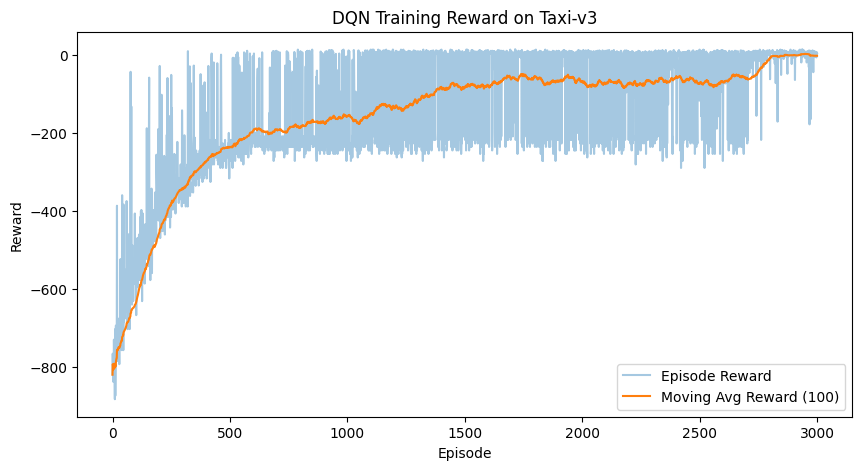

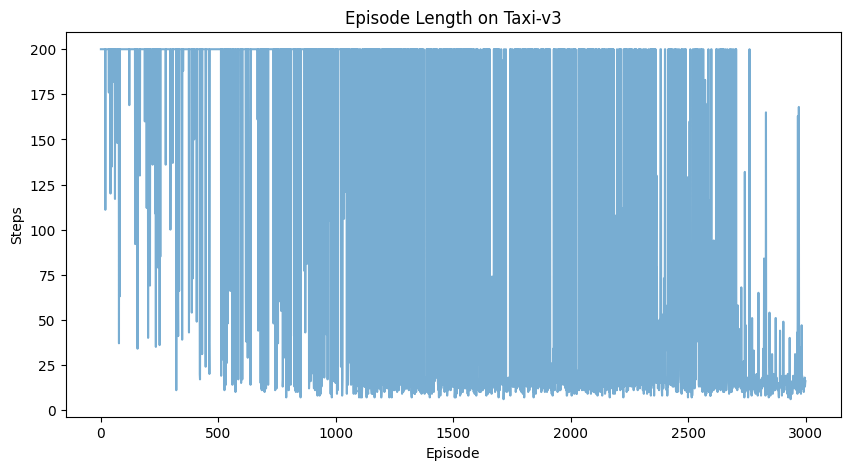

In [18]:
# 13. 학습 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.4, label="Episode Reward")
plt.plot(moving_avg_rewards, label="Moving Avg Reward (100)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN Training Reward on Taxi-v3")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(episode_lengths, alpha=0.6)
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("Episode Length on Taxi-v3")
plt.show()

### 학습된 정책 평가 코드

In [19]:
# 14. 학습된 정책 평가
def evaluate_policy(env, q_net, n_eval_episodes=100):
    rewards = []
    lengths = []

    for episode in range(n_eval_episodes):
        state, info = env.reset(seed=1000 + episode)
        state_vec = encode_state(state)

        done = False
        total_reward = 0
        step_count = 0

        while not done:
            state_tensor = torch.FloatTensor(state_vec).unsqueeze(0).to(device)

            with torch.no_grad():
                q_values = q_net(state_tensor)
                action = torch.argmax(q_values, dim=1).item()

            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            state_vec = encode_state(next_state)
            total_reward += reward
            step_count += 1

        rewards.append(total_reward)
        lengths.append(step_count)

    return np.mean(rewards), np.mean(lengths)

eval_env = gym.make("Taxi-v3")
avg_reward, avg_length = evaluate_policy(eval_env, q_net, n_eval_episodes=100)

print(f"Average evaluation reward: {avg_reward:.2f}")
print(f"Average evaluation steps : {avg_length:.2f}")

eval_env.close()

Average evaluation reward: -6.81
Average evaluation steps : 26.34


## 실제로 렌더링 해보기

In [20]:
# 15. 학습된 정책 시연
demo_env = gym.make("Taxi-v3", render_mode="ansi")

for episode in range(3):
    state, info = demo_env.reset(seed=2000 + episode)
    state_vec = encode_state(state)
    done = False
    total_reward = 0

    print(f"\n===== Demo Episode {episode+1} =====")
    print(demo_env.render())

    while not done:
        state_tensor = torch.FloatTensor(state_vec).unsqueeze(0).to(device)

        with torch.no_grad():
            q_values = q_net(state_tensor)
            action = torch.argmax(q_values, dim=1).item()

        next_state, reward, terminated, truncated, info = demo_env.step(action)
        done = terminated or truncated

        state_vec = encode_state(next_state)
        total_reward += reward

        print(demo_env.render())

    print("Total reward:", total_reward)

demo_env.close()


===== Demo Episode 1 =====
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Pickup)

+---------+
|R: | :_:G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

+---------+
|R: |_: :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

+---------+
|R: | : :G|
| : |_: : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

+---------+
|R: | : :G|
| : | : : |
| : :_: : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

+---------+
|R: | : :G|
| : | : : |
| :_: : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

+---------+
|R: | : :G|
| : | : : |
|_: : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

+---------+
|R: | : :G|
| : | : : 

# 추가 분석: 수업 때 배운 택시 알고리즘과 DQN 비교

아래 셀들은 **기존 코드에는 손대지 않고, 뒤에만 추가**한 비교/확장 실험이다.

## 1) 수업 때 배운 Q-learning과 DQN의 차이
- **Q-learning**: 각 상태-행동 쌍마다 Q값을 **Q-table**에 직접 저장한다.
- **DQN**: Q-table 대신 **신경망**으로 Q(s,a)를 근사한다.
- 따라서 작은 Taxi-v3(500 states, 6 actions)에서는 Q-learning도 충분히 가능하지만, 상태 수가 커질수록 Q-table 방식은 비효율적이 된다.
- DQN은 수업에서 배운 것처럼 **experience replay**와 **fixed target network**를 사용해 학습 안정성을 높인다.

## 2) 스케일러빌리티 비교
- 기본 Taxi-v3는 상태 수가 고정되어 있어서 map 크기를 키우는 비교가 어렵다.
- 그래서 아래에서는 **Taxi 규칙을 유지한 확장형 custom environment**를 추가해,
  map 크기를 늘릴 때 Q-learning과 DQN이 어떻게 달라지는지 비교한다.
- 핵심 비교 포인트:
  1. 평균 보상
  2. 평균 step 수
  3. Q-table 크기(state × action)
  4. DQN 파라미터 수


In [21]:
# ================================
# 1: 확장형 Taxi 환경 정의
# ================================
import math
from gymnasium import spaces

class ScalableTaxiEnv(gym.Env):
    metadata = {"render_modes": ["ansi"]}

    def __init__(self, grid_size=5, max_steps=300, render_mode=None):
        super().__init__()
        self.grid_size = grid_size
        self.max_steps = max_steps
        self.render_mode = render_mode

        # 승객/목적지 위치: 네 모서리
        self.locs = [
            (0, 0),
            (0, grid_size - 1),
            (grid_size - 1, 0),
            (grid_size - 1, grid_size - 1),
        ]

        # state = taxi_row, taxi_col, passenger_loc(0~3, in_taxi=4), destination(0~3)
        self.n_passenger_states = len(self.locs) + 1
        self.n_destination_states = len(self.locs)
        self.observation_space = spaces.Discrete(
            grid_size * grid_size * self.n_passenger_states * self.n_destination_states
        )
        self.action_space = spaces.Discrete(6)  # south, north, east, west, pickup, dropoff

        self.state = None
        self.steps = 0

    def encode(self, taxi_row, taxi_col, passenger_loc, destination):
        i = taxi_row
        i = i * self.grid_size + taxi_col
        i = i * self.n_passenger_states + passenger_loc
        i = i * self.n_destination_states + destination
        return i

    def decode(self, state):
        out = []
        out.append(state % self.n_destination_states)
        state //= self.n_destination_states
        out.append(state % self.n_passenger_states)
        state //= self.n_passenger_states
        out.append(state % self.grid_size)
        state //= self.grid_size
        out.append(state)
        taxi_row = out[3]
        taxi_col = out[2]
        passenger_loc = out[1]
        destination = out[0]
        return taxi_row, taxi_col, passenger_loc, destination

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.steps = 0

        taxi_row = self.np_random.integers(0, self.grid_size)
        taxi_col = self.np_random.integers(0, self.grid_size)
        passenger_loc = self.np_random.integers(0, len(self.locs))
        destination = self.np_random.integers(0, len(self.locs))

        while destination == passenger_loc:
            destination = self.np_random.integers(0, len(self.locs))

        self.state = self.encode(taxi_row, taxi_col, passenger_loc, destination)
        return int(self.state), {}

    def step(self, action):
        taxi_row, taxi_col, passenger_loc, destination = self.decode(int(self.state))
        reward = -1
        terminated = False
        truncated = False

        if action == 0:   # south
            taxi_row = min(taxi_row + 1, self.grid_size - 1)
        elif action == 1: # north
            taxi_row = max(taxi_row - 1, 0)
        elif action == 2: # east
            taxi_col = min(taxi_col + 1, self.grid_size - 1)
        elif action == 3: # west
            taxi_col = max(taxi_col - 1, 0)
        elif action == 4: # pickup
            if passenger_loc < len(self.locs) and (taxi_row, taxi_col) == self.locs[passenger_loc]:
                passenger_loc = len(self.locs)  # in taxi
            else:
                reward = -10
        elif action == 5: # dropoff
            if passenger_loc == len(self.locs) and (taxi_row, taxi_col) == self.locs[destination]:
                reward = 20
                terminated = True
            elif passenger_loc == len(self.locs) and (taxi_row, taxi_col) in self.locs:
                passenger_loc = self.locs.index((taxi_row, taxi_col))
                reward = -1
            else:
                reward = -10

        self.state = self.encode(taxi_row, taxi_col, passenger_loc, destination)
        self.steps += 1

        if self.steps >= self.max_steps and not terminated:
            truncated = True

        return int(self.state), reward, terminated, truncated, {}

    def render(self):
        taxi_row, taxi_col, passenger_loc, destination = self.decode(int(self.state))
        grid = [["." for _ in range(self.grid_size)] for _ in range(self.grid_size)]

        for idx, (r, c) in enumerate(self.locs):
            grid[r][c] = str(idx)

        if passenger_loc < len(self.locs):
            pr, pc = self.locs[passenger_loc]
            grid[pr][pc] = "P"

        dr, dc = self.locs[destination]
        grid[dr][dc] = "D"

        grid[taxi_row][taxi_col] = "T"

        return "\n".join(" ".join(row) for row in grid)


In [22]:
# ================================
# 2: 비교용 학습 함수
# ================================
def train_q_learning_scalable(grid_size=5, num_episodes=2000, max_steps=None,
                              alpha=0.1, gamma=0.99,
                              epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995,
                              seed=42):
    env = ScalableTaxiEnv(grid_size=grid_size, max_steps=max_steps or grid_size * grid_size * 4)
    np.random.seed(seed)
    random.seed(seed)

    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q_table_cmp = np.zeros((n_states, n_actions), dtype=np.float32)

    reward_window = deque(maxlen=100)
    moving_avg = []

    for episode in range(num_episodes):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0
        step_count = 0

        for _ in range(env.max_steps):
            if np.random.rand() < epsilon:
                action = np.random.randint(n_actions)
            else:
                action = np.argmax(Q_table_cmp[state])

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            best_next_q = np.max(Q_table_cmp[next_state])
            td_target = reward + gamma * best_next_q * (1 - float(done))
            td_error = td_target - Q_table_cmp[state, action]
            Q_table_cmp[state, action] += alpha * td_error

            state = next_state
            total_reward += reward
            step_count += 1

            if done:
                break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        reward_window.append(total_reward)
        moving_avg.append(np.mean(reward_window))

    return {
        "env": env,
        "Q_table": Q_table_cmp,
        "moving_avg_rewards": moving_avg,
        "final_avg_reward": float(np.mean(reward_window)),
        "qtable_entries": int(Q_table_cmp.size),
    }


def evaluate_q_learning_scalable(env, Q_table, n_eval_episodes=100, seed=1234):
    rewards, lengths = [], []

    for ep in range(n_eval_episodes):
        state, _ = env.reset(seed=seed + ep)
        total_reward = 0
        step_count = 0

        for _ in range(env.max_steps):
            action = int(np.argmax(Q_table[state]))
            next_state, reward, terminated, truncated, _ = env.step(action)
            state = next_state
            total_reward += reward
            step_count += 1
            if terminated or truncated:
                break

        rewards.append(total_reward)
        lengths.append(step_count)

    return float(np.mean(rewards)), float(np.mean(lengths))


def train_dqn_scalable(grid_size=5, num_episodes=2000, max_steps=None,
                       gamma=0.99, learning_rate=1e-3,
                       epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995,
                       batch_size=64, buffer_size=10000, target_update_freq=20,
                       seed=42):
    env = ScalableTaxiEnv(grid_size=grid_size, max_steps=max_steps or grid_size * grid_size * 4)
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)

    n_states_local = env.observation_space.n
    n_actions_local = env.action_space.n

    def encode_state_local(state):
        x = np.zeros(n_states_local, dtype=np.float32)
        x[state] = 1.0
        return x

    q_net_cmp = QNetwork(n_states_local, n_actions_local).to(device)
    target_net_cmp = QNetwork(n_states_local, n_actions_local).to(device)
    target_net_cmp.load_state_dict(q_net_cmp.state_dict())
    target_net_cmp.eval()

    optimizer_cmp = optim.Adam(q_net_cmp.parameters(), lr=learning_rate)
    memory_cmp = ReplayBuffer(buffer_size)

    reward_window = deque(maxlen=100)
    moving_avg = []

    def select_action(state_vec, epsilon_now):
        if np.random.rand() < epsilon_now:
            return np.random.randint(n_actions_local)
        state_tensor = torch.FloatTensor(state_vec).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = q_net_cmp(state_tensor)
        return int(torch.argmax(q_values, dim=1).item())

    def train_step_local():
        if len(memory_cmp) < batch_size:
            return
        states, actions, rewards, next_states, dones = memory_cmp.sample(batch_size)

        states = torch.FloatTensor(states).to(device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(next_states).to(device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

        current_q = q_net_cmp(states).gather(1, actions)
        with torch.no_grad():
            next_q = target_net_cmp(next_states).max(dim=1, keepdim=True)[0]
            target_q = rewards + gamma * next_q * (1 - dones)

        loss = F.mse_loss(current_q, target_q)
        optimizer_cmp.zero_grad()
        loss.backward()
        optimizer_cmp.step()

    for episode in range(num_episodes):
        state, _ = env.reset(seed=seed + episode)
        state_vec = encode_state_local(state)

        total_reward = 0
        step_count = 0

        for _ in range(env.max_steps):
            action = select_action(state_vec, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            next_state_vec = encode_state_local(next_state)
            memory_cmp.push(state_vec, action, reward, next_state_vec, done)
            train_step_local()

            state_vec = next_state_vec
            total_reward += reward
            step_count += 1

            if done:
                break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        if (episode + 1) % target_update_freq == 0:
            target_net_cmp.load_state_dict(q_net_cmp.state_dict())

        reward_window.append(total_reward)
        moving_avg.append(np.mean(reward_window))

    n_params = sum(p.numel() for p in q_net_cmp.parameters())

    return {
        "env": env,
        "q_net": q_net_cmp,
        "moving_avg_rewards": moving_avg,
        "final_avg_reward": float(np.mean(reward_window)),
        "network_params": int(n_params),
        "state_dim": int(n_states_local),
    }


def evaluate_dqn_scalable(env, q_net_model, n_eval_episodes=100, seed=1234):
    rewards, lengths = [], []
    n_states_local = env.observation_space.n

    def encode_state_local(state):
        x = np.zeros(n_states_local, dtype=np.float32)
        x[state] = 1.0
        return x

    for ep in range(n_eval_episodes):
        state, _ = env.reset(seed=seed + ep)
        total_reward = 0
        step_count = 0

        for _ in range(env.max_steps):
            state_vec = torch.FloatTensor(encode_state_local(state)).unsqueeze(0).to(device)
            with torch.no_grad():
                action = int(torch.argmax(q_net_model(state_vec), dim=1).item())

            next_state, reward, terminated, truncated, _ = env.step(action)
            state = next_state
            total_reward += reward
            step_count += 1

            if terminated or truncated:
                break

        rewards.append(total_reward)
        lengths.append(step_count)

    return float(np.mean(rewards)), float(np.mean(lengths))


In [23]:
# ================================
# 3: map 크기 늘려가며 scalability 비교
# ================================
grid_sizes = [5, 10, 15]
comparison_results = []

for g in grid_sizes:
    print(f"\n===== Grid Size: {g}x{g} =====")

    q_result = train_q_learning_scalable(grid_size=g, num_episodes=1500, seed=SEED)
    q_eval_reward, q_eval_len = evaluate_q_learning_scalable(q_result["env"], q_result["Q_table"])

    dqn_result = train_dqn_scalable(grid_size=g, num_episodes=1500, seed=SEED)
    dqn_eval_reward, dqn_eval_len = evaluate_dqn_scalable(dqn_result["env"], dqn_result["q_net"])

    comparison_results.append({
        "grid_size": f"{g}x{g}",
        "num_states": q_result["env"].observation_space.n,
        "Q-learning avg reward": round(q_eval_reward, 2),
        "Q-learning avg steps": round(q_eval_len, 2),
        "Q-table entries": q_result["qtable_entries"],
        "DQN avg reward": round(dqn_eval_reward, 2),
        "DQN avg steps": round(dqn_eval_len, 2),
        "DQN state dim": dqn_result["state_dim"],
        "DQN params": dqn_result["network_params"],
    })

import pandas as pd
comparison_df = pd.DataFrame(comparison_results)
comparison_df



===== Grid Size: 5x5 =====

===== Grid Size: 10x10 =====

===== Grid Size: 15x15 =====


,grid_size,num_states,Q-learning avg reward,Q-learning avg steps,Q-table entries,DQN avg reward,DQN avg steps,DQN state dim,DQN params
0,5x5,500,-13.50,29.88,3000,9.89,11.11,500,81414
1,10x10,2000,-646.46,396.11,12000,-400.00,400.00,2000,273414
2,15x15,4500,-1465.74,900.00,27000,-900.00,900.00,4500,593414


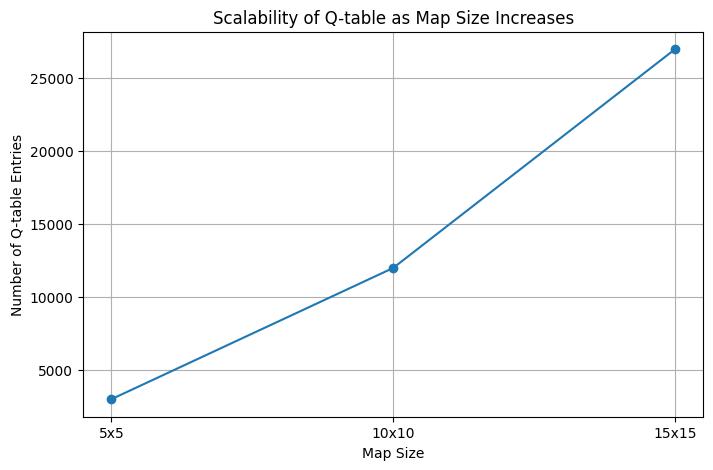

In [24]:
# ================================
# 4: Q-table 크기 증가 시각화
# ================================
plt.figure(figsize=(8, 5))
plt.plot(comparison_df["grid_size"], comparison_df["Q-table entries"], marker="o")
plt.xlabel("Map Size")
plt.ylabel("Number of Q-table Entries")
plt.title("Scalability of Q-table as Map Size Increases")
plt.grid(True)
plt.show()

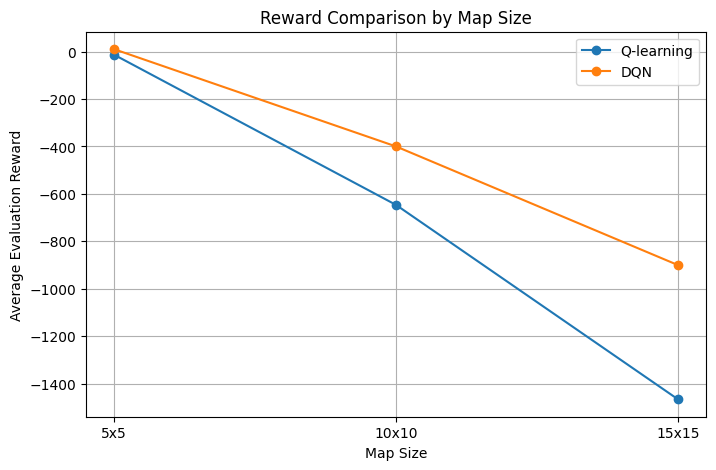

In [25]:
# ================================
# 5: 알고리즘별 성능 비교 시각화
# ================================
plt.figure(figsize=(8, 5))
plt.plot(comparison_df["grid_size"], comparison_df["Q-learning avg reward"], marker="o", label="Q-learning")
plt.plot(comparison_df["grid_size"], comparison_df["DQN avg reward"], marker="o", label="DQN")
plt.xlabel("Map Size")
plt.ylabel("Average Evaluation Reward")
plt.title("Reward Comparison by Map Size")
plt.legend()
plt.grid(True)
plt.show()


- **기본 Taxi-v3에서는** 상태 수가 500으로 제한되어 있어 Q-learning도 충분히 학습 가능하다.
- 하지만 **map 크기를 키우면 상태 수가 빠르게 증가**하고, Q-learning은 각 상태-행동마다 값을 저장해야 해서 Q-table이 커진다.
- 반면 **DQN은 Q값을 신경망으로 근사**하므로, 상태 수가 커져도 table 자체를 전부 저장하지 않고 학습할 수 있다.
- 따라서 이 실험은 **작은 문제에서는 Q-learning이 단순하고 효과적이지만, 큰 문제에서는 DQN이 더 scalable한 접근**이라는 점을 보여준다.

### 결론
> 수업 때 배운 Q-learning은 작은 Taxi 환경에서는 강력하지만, 상태공간이 커질수록 table 기반 표현의 한계가 나타나고, DQN은 함수근사를 사용해 더 큰 환경으로 확장하기 쉽다.
